In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
#%load_ext line_profiler
#%load_ext snakeviz
%autoreload 2

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import corner

import pickle

import enterprise
from enterprise.pulsar import Pulsar
import enterprise.signals.parameter as parameter
from enterprise.signals import utils
from enterprise.signals import signal_base
from enterprise.signals import selections
from enterprise.signals.selections import Selection
from enterprise.signals import white_signals
from enterprise.signals import gp_signals
from enterprise.signals import deterministic_signals
import enterprise.constants as const

from enterprise_extensions import deterministic

from scipy.stats import norm

import libstempo as T2
import libstempo.toasim as LT
import libstempo.plot as LP

import glob
import json
import h5py
import healpy as hp
import scipy.constants as sc
import emcee

from numba.typed import List

import sys
import h5py

In [2]:
target_d_L = 75.4#Mpc

In [3]:
base = "IPTA_MDC2_G2D1_narrow_detection_dL_75.4_"
crnr_plt_title1 =base+'corner plot_all_params'
crnr_plt_title2 =base
trace_plot_title = base+'trace_plot'
BF_histogram_title = base+'log10A_histogram'
BFerr_title = base+'log10A_histogram_error'

In [4]:
pwd

'/scratch/na00078/projects/IPTA_MDC2/post_processing'

## Generate Outfile

## Run Outfile

In [5]:
#COMMENT IF OUTFILE GENERATED
#Thinning script for one source
i = "/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_narrow_detect_outfile.h5"
infile = i
first_n_param = 8
# outfile = '/scratch/na00078/QuickCW_targeted_runs/results/3C66B_outfile.h5'

print(infile)
print(first_n_param)

with h5py.File(infile, 'r') as f:
    Ts = f['T-ladder'][...]
    samples_cold = f['samples_cold'][:,:,:first_n_param]
    print(samples_cold[-1].shape)
    log_likelihood = f['log_likelihood'][:1,:]
    print(log_likelihood.shape)
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
    acc_fraction = f['acc_fraction'][...]
    fisher_diag = f['fisher_diag'][...]

/scratch/na00078/projects/IPTA_MDC2/h5_files/G2D1_narrow_detect_outfile.h5
8
(100000000, 8)
(1, 100000000)


## Corner Plots

In [6]:
KPC2S = sc.parsec / sc.c * 1e3
SOLAR2S = sc.G / sc.c ** 3 * 1.98855e30


xxx0 = {"0_cos_gwtheta":np.cos(0.6387905062299246),
       "0_cos_inc":0.8412486994612669,
       "0_gwphi":3.3335788713091694,
       "0_log10_fgw":np.log10(3.7e-09),
       "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651,
        "distance": 75.4,}


xxx = {
       "0_cos_inc":0.8412486994612669,
        "0_log10_h":-13.668773493298787,
       "0_log10_mc":np.log10(4300000000),
       "phase0": 0.24434609527920614,
        "psi": 1.1187560505283651}

xxx['gwb_gamma'] = np.nan    
xxx['gwb_log10_A'] = -15.070581074285707
    
#print(xxx)

# In[6]:




hamp [1.8479137e-17 1.1155430e-15 1.7973355e-18 ... 5.4829422e-16 4.0192150e-16
 1.5026009e-18]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [3.1150256e+08 1.8709566e+07 3.3609171e+10 ... 3.7796096e+09 3.7796096e+09
 2.2273494e+07]
Length of logdL 100000000
required values 8.485007 3.7000025e-09 33609170000.0 1.9941068e-15
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [1.1011821e+03 1.6803181e-01 2.7684636e+07 ... 2.3777678e+03 3.2437090e+03
 1.6681760e+02]
min 10**log10_d_L 0.0008260285
max 10**log10_d_L 305497250.0
d_L_mask [    3775     6258    10426 ... 99998694 99998695 99998696]
notd_L_mask1 [       1        3        7 ... 99999880 99999948 99999955]
notd_L_mask2 [       0        2        4 ... 99999997 99999998 99999999]
merged_non_dL [       1        3        7 ... 99999997 99999998 99999999]
Sample shape (100000000, 9)
dL_mask length 130679
5
Max Mc sampled 9.904482


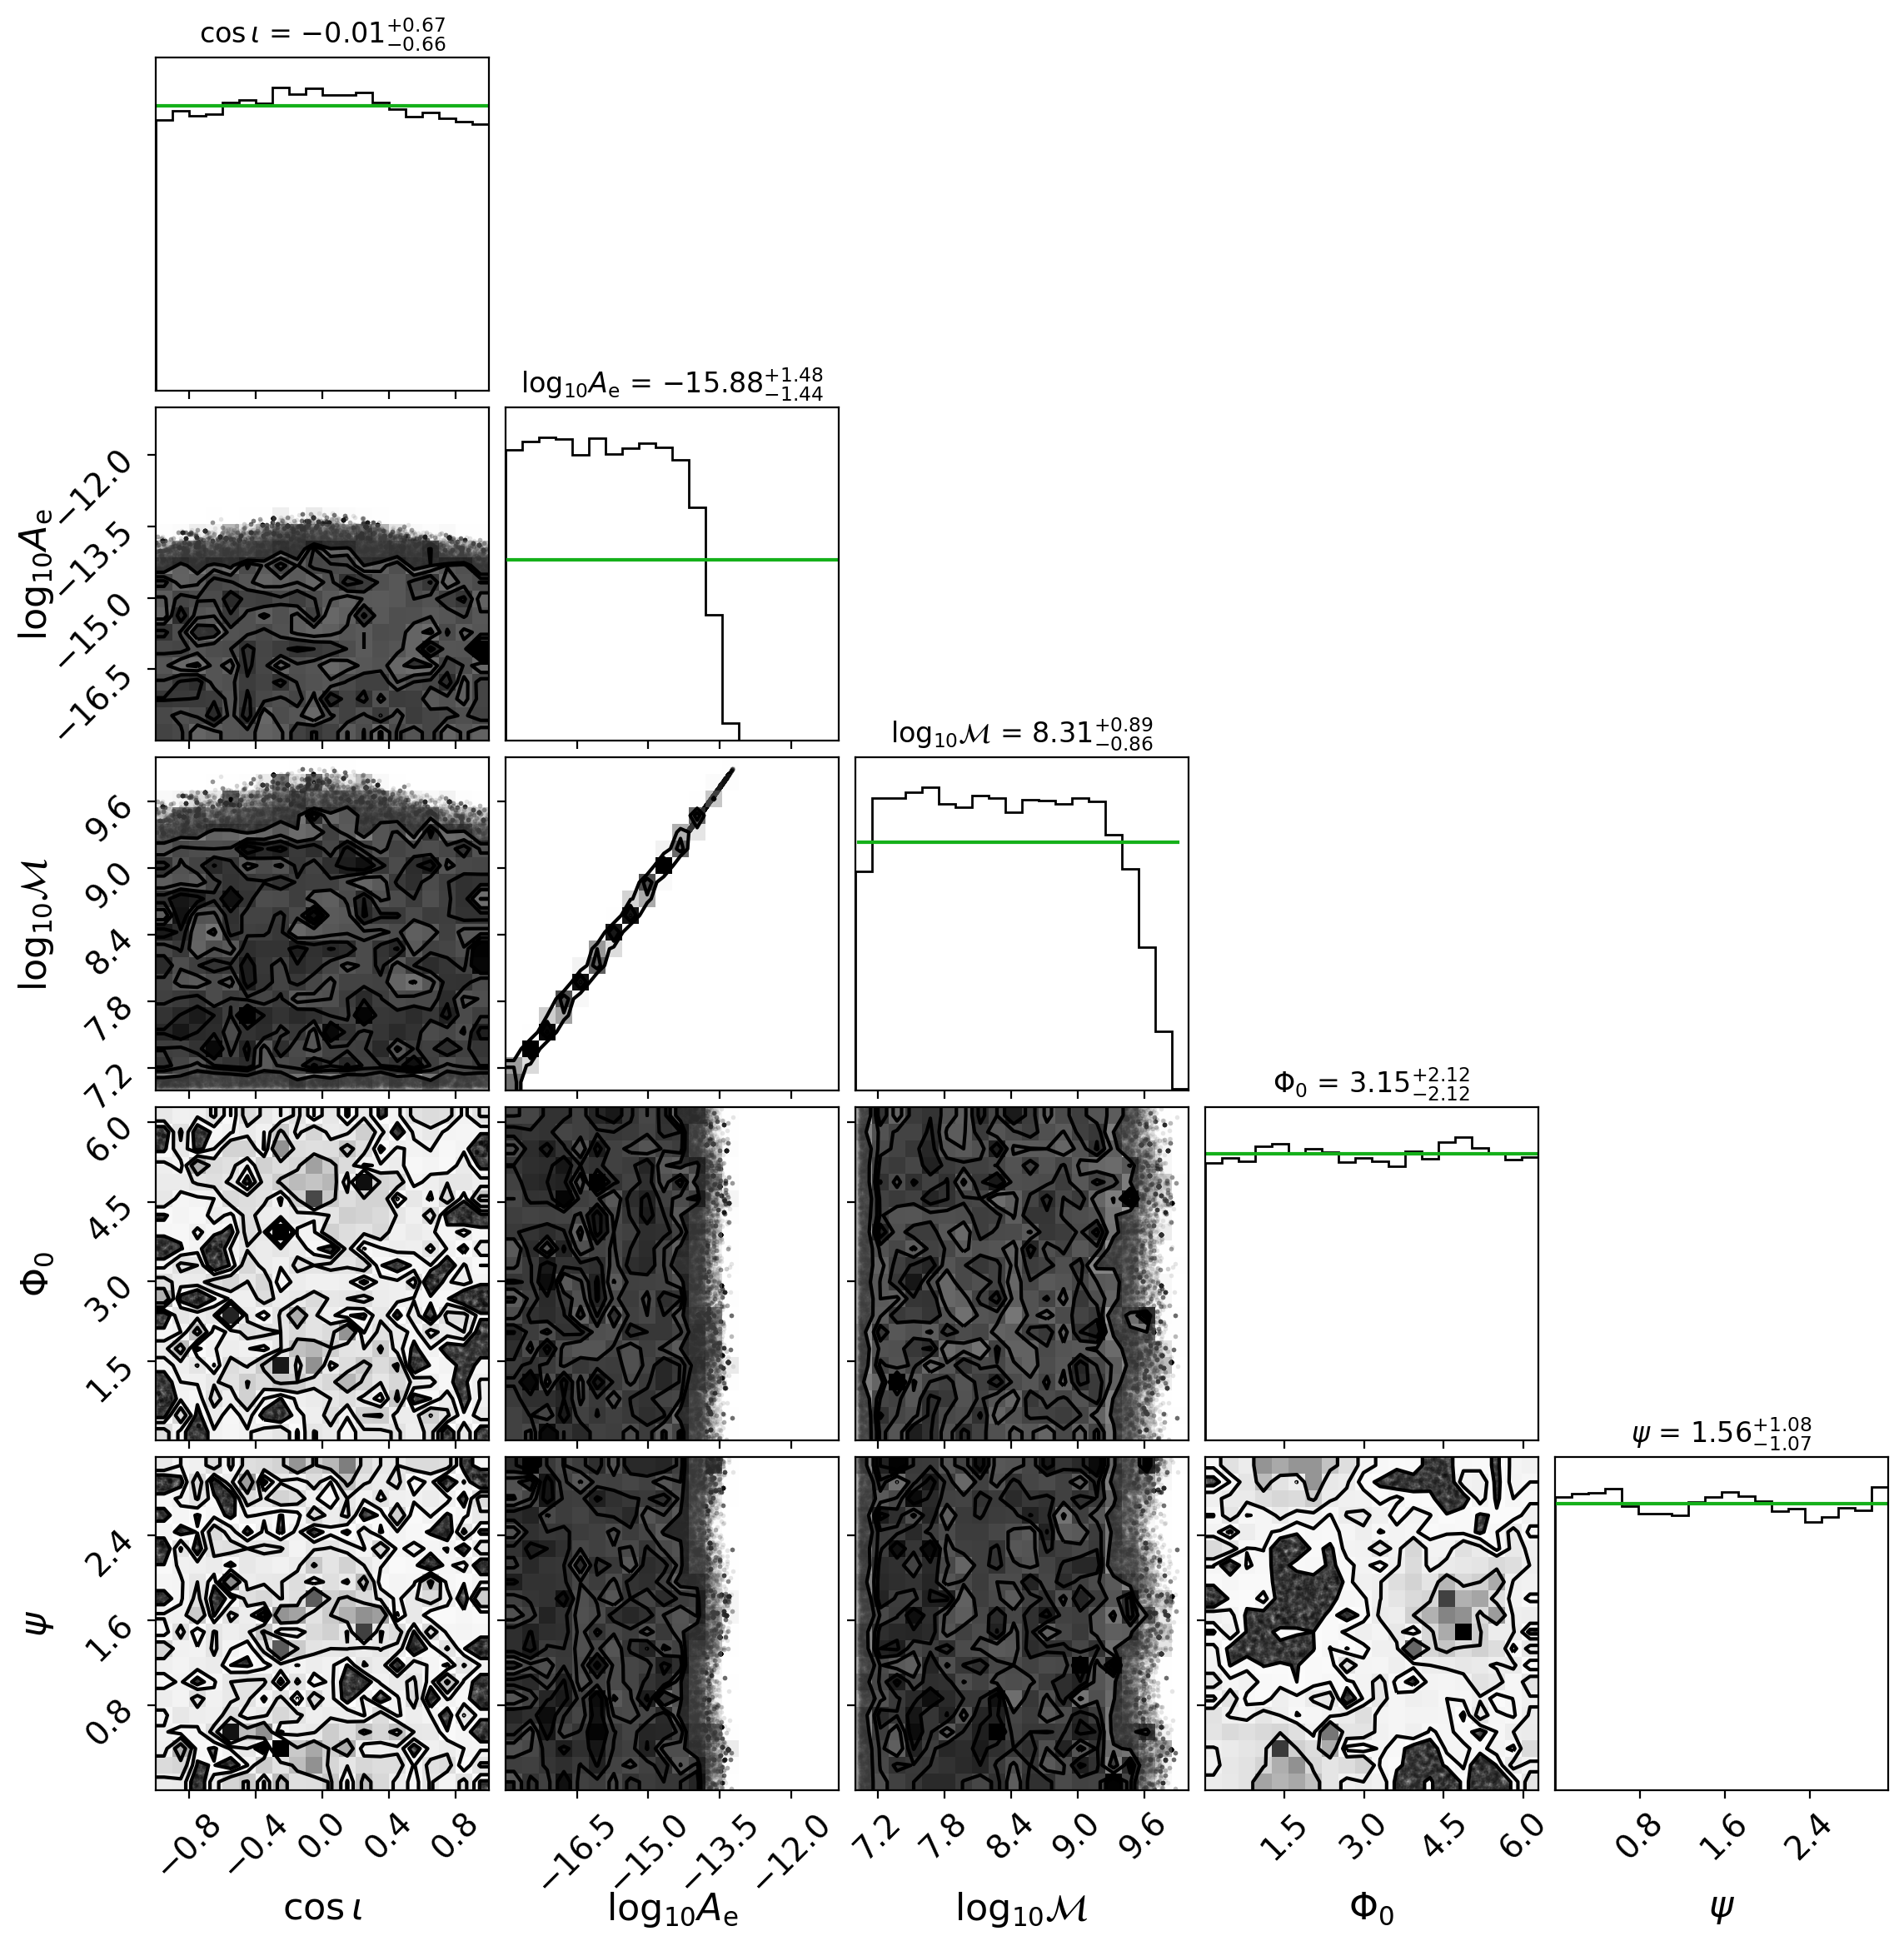

In [17]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
#labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
      #    r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
labels = [r"$\cos \iota$", r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$",r"$\psi$"]

label_to_key = {
    r"$\cos \iota$": "0_cos_inc",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi"
}

# Now build the truths array by translating labels
truths = [xxx[label_to_key[l]] for l in labels]


#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-18,-11), (7,10), (0,2*np.pi), (0,np.pi)]
#ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.704,np.log10(3e-7)), (-18,-11), (6.6,12), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################

d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

print("Max Mc sampled", np.max(samples2plot[d_L_mask,5]))

samples2plot_detect = np.vstack((
                          samples2plot[d_L_mask,1],
                          samples2plot[d_L_mask,4],
                          samples2plot[d_L_mask,5],
                          samples2plot[d_L_mask,6],
                          samples2plot[d_L_mask,7])).T


#fig = corner.corner(samples2plot_detect,
  #                  labels=labels,
   #                 show_titles=True, quantiles=[0.16, 0.5, 0.84],
    #                range=ranges, hist_kwargs={"density":True})
    
fig = corner.corner(
    samples2plot_detect,
    labels=labels,
    show_titles=True,
    range=ranges,
    hist_kwargs={"density": True})
    #truths=truths,
    #truth_color="red"   # optional, highlights them in red)

for ax in fig.get_axes():
    ax.tick_params(axis="both", labelsize=14)   # tick labels
    ax.xaxis.label.set_size(16)                 # x-axis label
    ax.yaxis.label.set_size(16)                 # y-axis label

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0:#(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    #elif i==3*(len(labels)+1): #log10_fgw
     #   Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
      #  ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==2*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(np.min(samples2plot[d_L_mask,5]), np.max(samples2plot[d_L_mask,5]))
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==3*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==4*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")

#fig.suptitle(crnr_plt_title1, fontsize = 25,y=1.05);

hamp [1.8479137e-17 1.1155430e-15 1.7973355e-18 ... 5.4829422e-16 4.0192150e-16
 1.5026009e-18]
freq [3.7000025e-09 3.7000025e-09 3.7000025e-09 ... 3.7000025e-09 3.7000025e-09
 3.7000025e-09]
mc [3.1150256e+08 1.8709566e+07 3.3609171e+10 ... 3.7796096e+09 3.7796096e+09
 2.2273494e+07]
Length of logdL 100000000
required values 8.485007e+00 3.7000025e-09 33609170000.0 1.9941068e-15
dL min 74.646
dL max 76.15400000000001
10**log10_d_L [1.1011821e+03 1.6803181e-01 2.7684636e+07 ... 2.3777678e+03 3.2437090e+03
 1.6681760e+02]
min 10**log10_d_L 0.0008260285
max 10**log10_d_L 305497250.0
d_L_mask [    3775     6258    10426 ... 99998694 99998695 99998696]
notd_L_mask1 [       1        3        7 ... 99999880 99999948 99999955]
notd_L_mask2 [       0        2        4 ... 99999997 99999998 99999999]
merged_non_dL [       1        3        7 ... 99999997 99999998 99999999]
Sample shape (100000000, 9)
dL_mask length 130679
9


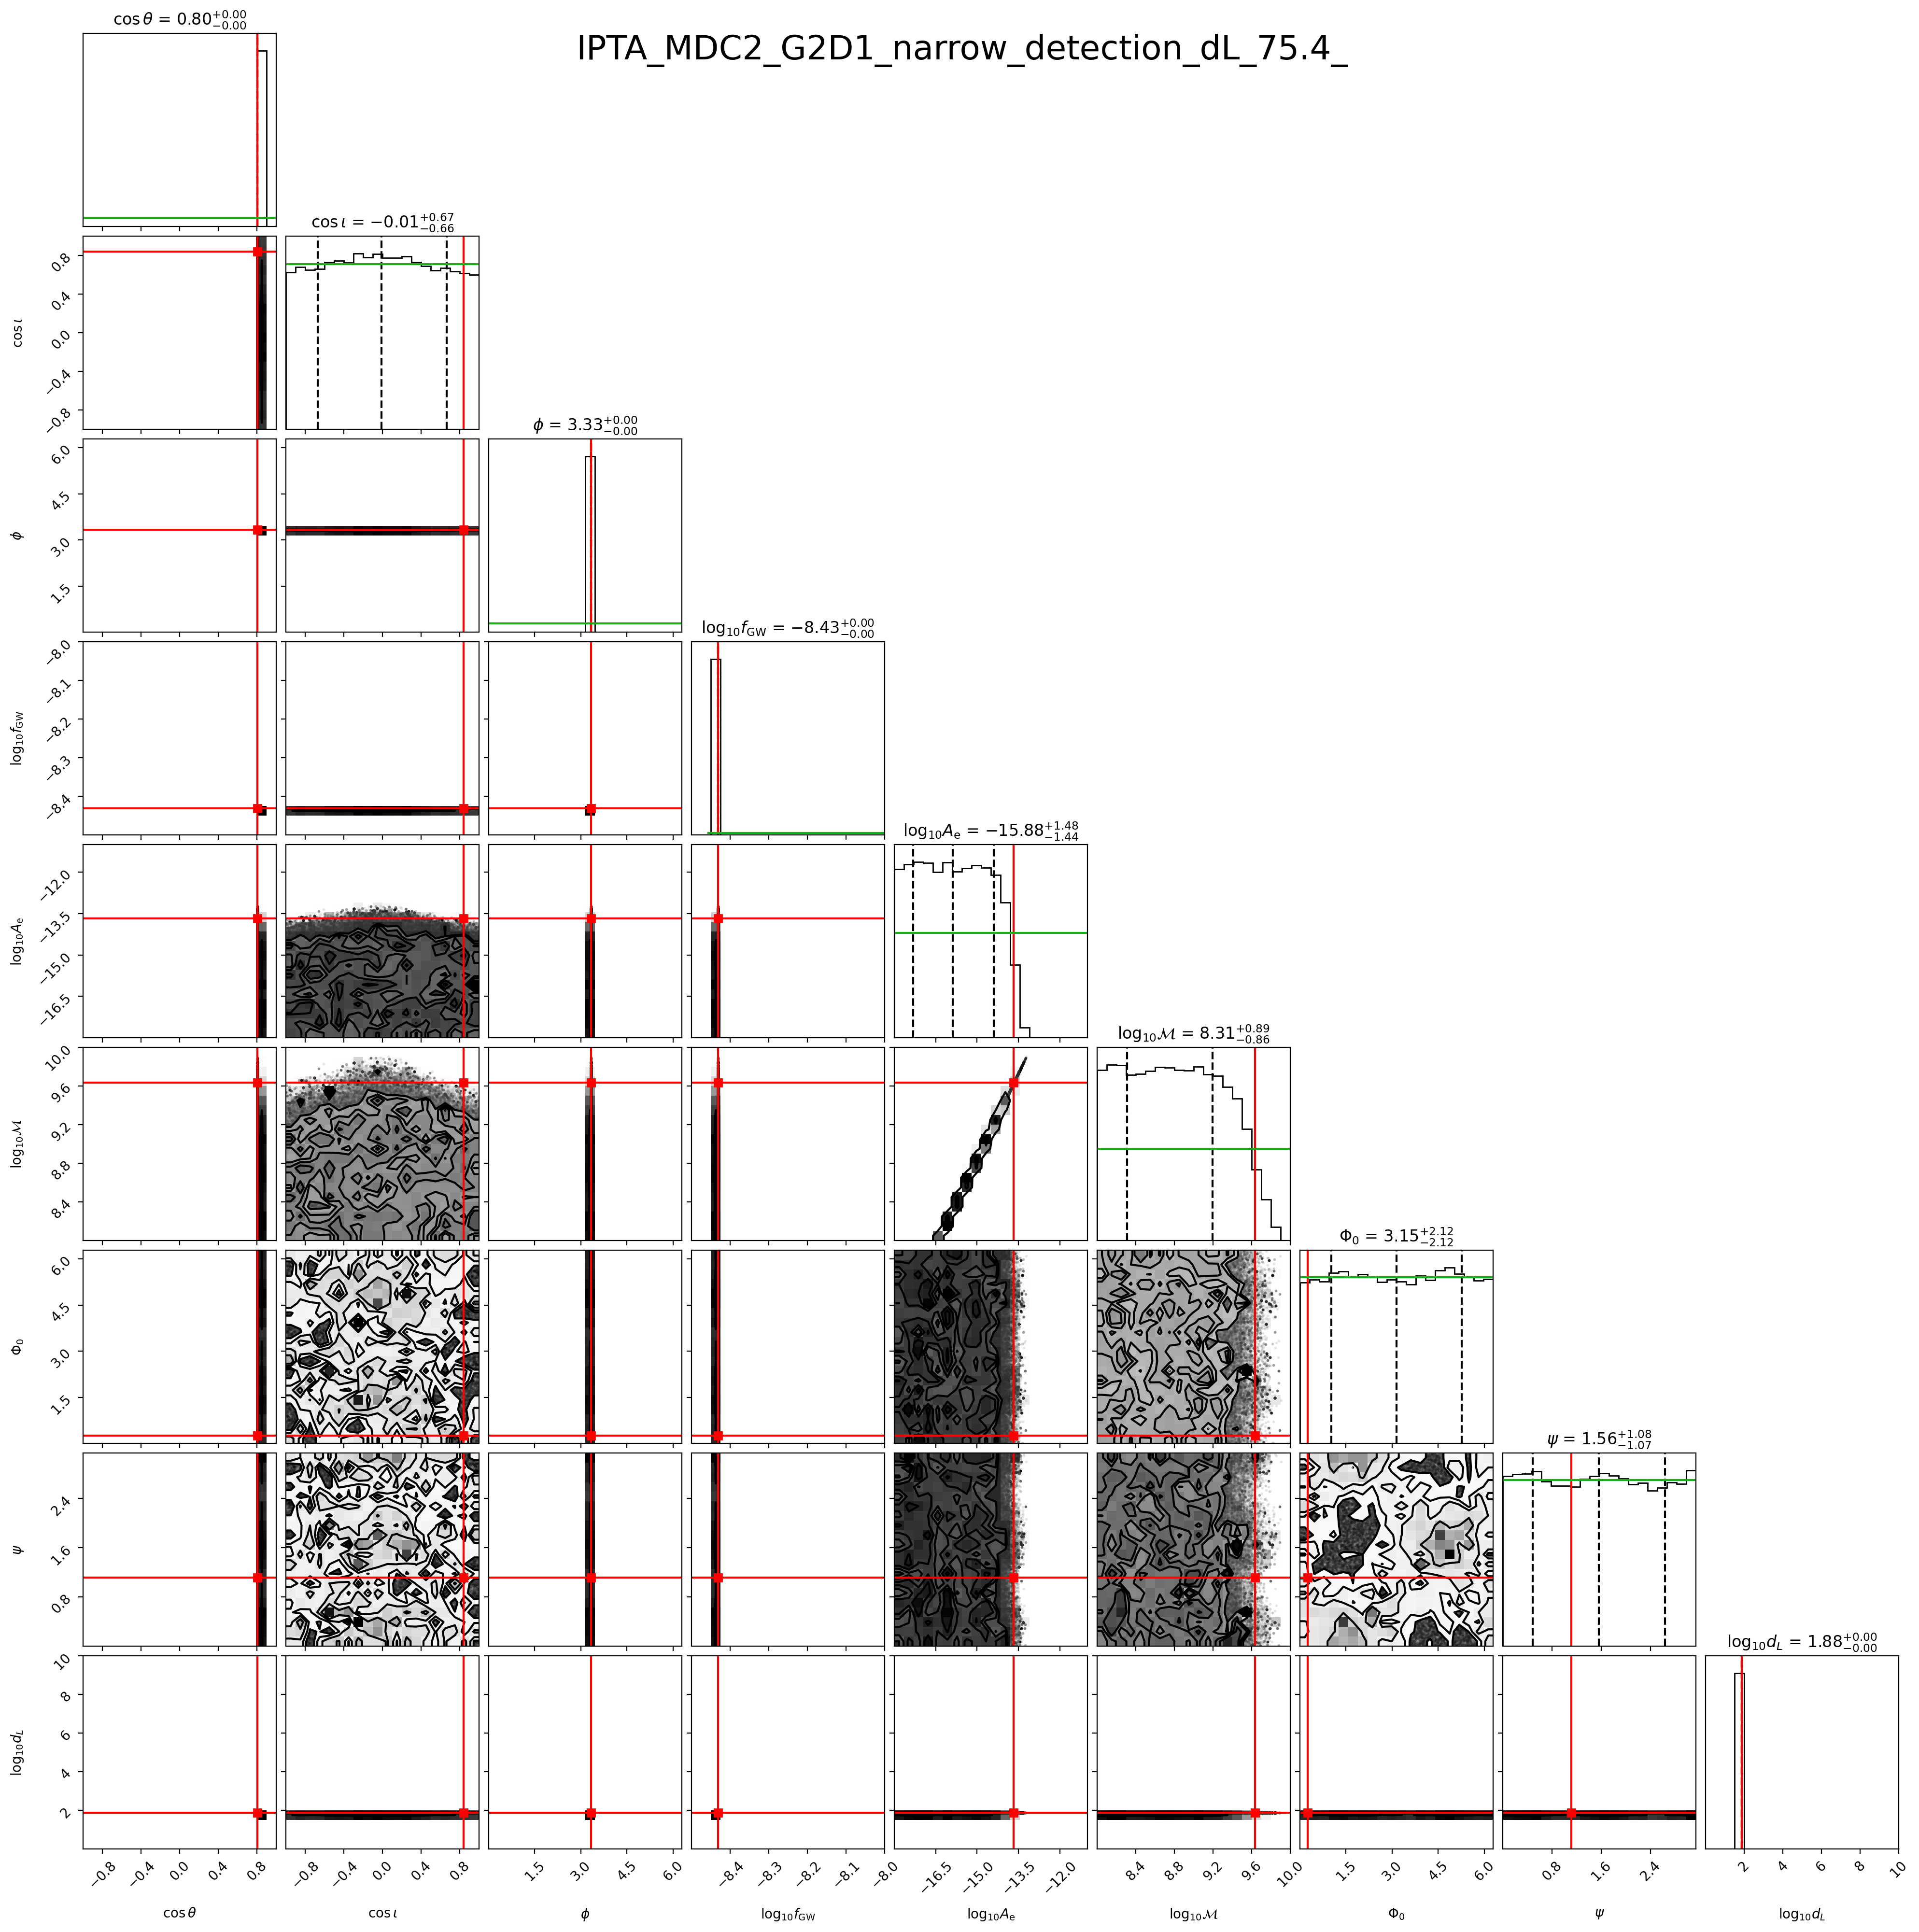

In [8]:
#corner plot of parameters common to all pulsars (Contains Luminosity distance)
corner_mask = [0, 1, 2, 3, 4, 5, 6, 7]
par_keys = ["0_cos_gwtheta", "0_cos_inc", "0_gwphi", "0_log10_fgw",
          "0_log10_h", "0_log10_mc", "0_phase0", "0_psi","log10_d_L"]
labels = [r"$\cos \theta$", r"$\cos \iota$", r"$\phi$", r"$\log_{10} f_{\rm GW}$",
          r"$\log_{10} A_{\rm e}$", r"$\log_{10} {\cal M}$", r"$\Phi_0$", r"$\psi$",r"$\log_{10} d_L$"]
          
# Mapping from pretty labels → xxx0 keys
label_to_key = {
    r"$\cos \theta$": "0_cos_gwtheta",
    r"$\cos \iota$": "0_cos_inc",
    r"$\phi$": "0_gwphi",
    r"$\log_{10} f_{\rm GW}$": "0_log10_fgw",
    r"$\log_{10} A_{\rm e}$": "0_log10_h",
    r"$\log_{10} {\cal M}$": "0_log10_mc",
    r"$\Phi_0$": "phase0",
    r"$\psi$": "psi",
    r"$\log_{10} d_L$": "distance"
}

# Build truths list (log-transform distance for d_L)
truths = []
for lab in labels:
    key = label_to_key[lab]
    if lab == r"$\log_{10} d_L$":
        truths.append(np.log10(xxx0[key]))
    else:
        truths.append(xxx0[key])
        
#set burnin and thinning
#burnin = 0
#burnin = 500_000
burnin = 0#int(1e6)
thin = 1

#set ranges
ranges = [(-1,1), (-1,1), (0,2*np.pi), (-8.5,-8), (-18,-11), (8,10), (0,2*np.pi), (0,np.pi), (0,10)]
#ranges = [0.99]*9


megaparsec = 3.086e+22 #meter
speed_of_light = 299792458.0 #m/s
T_sun = 1.327124400e20 / speed_of_light**3 #G*M_sun/c^3 = R_sun/c-->Sun time

############################################################################
h_amp = 10**samples_cold[0][burnin::thin,4]
fff = 10**samples_cold[0][burnin::thin,3]
mmm = 10**samples_cold[0][burnin::thin,5]

print('hamp',h_amp)
print('freq',fff)
print('mc',mmm)

log10_d_L = np.log10(2 * (mmm*T_sun)**(5/3) * (np.pi*fff)**(2/3) / h_amp *speed_of_light/megaparsec)
print("Length of logdL", len(log10_d_L))
print("required values",np.max(log10_d_L), fff[1000], mmm[1000], h_amp[1000] )
#####################################
target_d_L = 75.4#Mpc
d_L_percent_tolerance = 1.0
#####################################

d_L_min = target_d_L*(1-d_L_percent_tolerance/100)
d_L_max = target_d_L*(1+d_L_percent_tolerance/100)
print("dL min",d_L_min)
print("dL max",d_L_max)
print("10**log10_d_L",10**log10_d_L)
print("min 10**log10_d_L",np.min(10**log10_d_L))
print("max 10**log10_d_L",np.max(10**log10_d_L))

d_L_mask = np.where((10**log10_d_L>=d_L_min) & (10**log10_d_L<=d_L_max))[0]
print("d_L_mask",d_L_mask)

#########################
not_d_L_mask_1 = np.where((10**log10_d_L<d_L_min))[0] #& (10**log10_d_L>d_L_max))[0]
print("notd_L_mask1",not_d_L_mask_1)
not_d_L_mask_2 = np.where((10**log10_d_L>d_L_max))[0] #& ())[0]
print("notd_L_mask2",not_d_L_mask_2)

merged_non_dL = np.concatenate((not_d_L_mask_1,not_d_L_mask_2))
print("merged_non_dL",merged_non_dL)
########################################

samples2plot = np.concatenate((samples_cold[0][burnin::thin,corner_mask], np.array([log10_d_L,]).T), axis=1)

print("Sample shape", samples2plot.shape)
print("dL_mask length", len(d_L_mask))
print(len(ranges))

#fig = corner.corner(samples2plot[d_L_mask, :],
 #                   labels=labels,
  #                  show_titles=True, quantiles=[0.16, 0.5, 0.84],
   #                 range=ranges, hist_kwargs={"density":True})

fig = corner.corner(
    samples2plot[d_L_mask, :],   # <-- use samples2plot, not samples2plot_detect
    labels=labels,
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    range=ranges,
    hist_kwargs={"density": True},
    truths=truths,
    truth_color="red"
)

#plot priors over 1D posteriors
for i, ax in enumerate(fig.axes):
    if i==0 or i==(len(labels)+1): #cos inc and cos theta
        Xs = np.linspace(-1,1)
        ax.plot(Xs, Xs*0+1/2, color="xkcd:green")
    elif i==2*(len(labels)+1) or i==6*(len(labels)+1): #gwphi and phase0
        Xs = np.linspace(0,2*np.pi)
        ax.plot(Xs, Xs*0+1/(2*np.pi), color="xkcd:green")
    elif i==3*(len(labels)+1): #log10_fgw
        Xs = np.linspace(np.log10(3.5e-9), -7.0)
        # Y = plot_Gaussian(Xs,np.log10(1.13e-8),1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/(np.log10(3e-7)+8.704), color="xkcd:green")
    elif i==4*(len(labels)+1): #log10_A
        Xs = np.linspace(-18, -11)
        ax.plot(Xs, Xs*0+1/7, color="xkcd:green")
    elif i==5*(len(labels)+1): #log10_M_ch
        Xs = np.linspace(7.84, 10.26)
        # Y=plot_Gaussian(Xs,9.86,1)
        # ax.plot(Xs,Y, color='xkcd:green')
        ax.plot(Xs, Xs*0+1/3, color="xkcd:green")
    elif i==7*(len(labels)+1): #psi
        Xs = np.linspace(0,np.pi)
        ax.plot(Xs, Xs*0+1/np.pi, color="xkcd:green")
        
fig.suptitle(crnr_plt_title2, fontsize = 25);

## Trace Plots

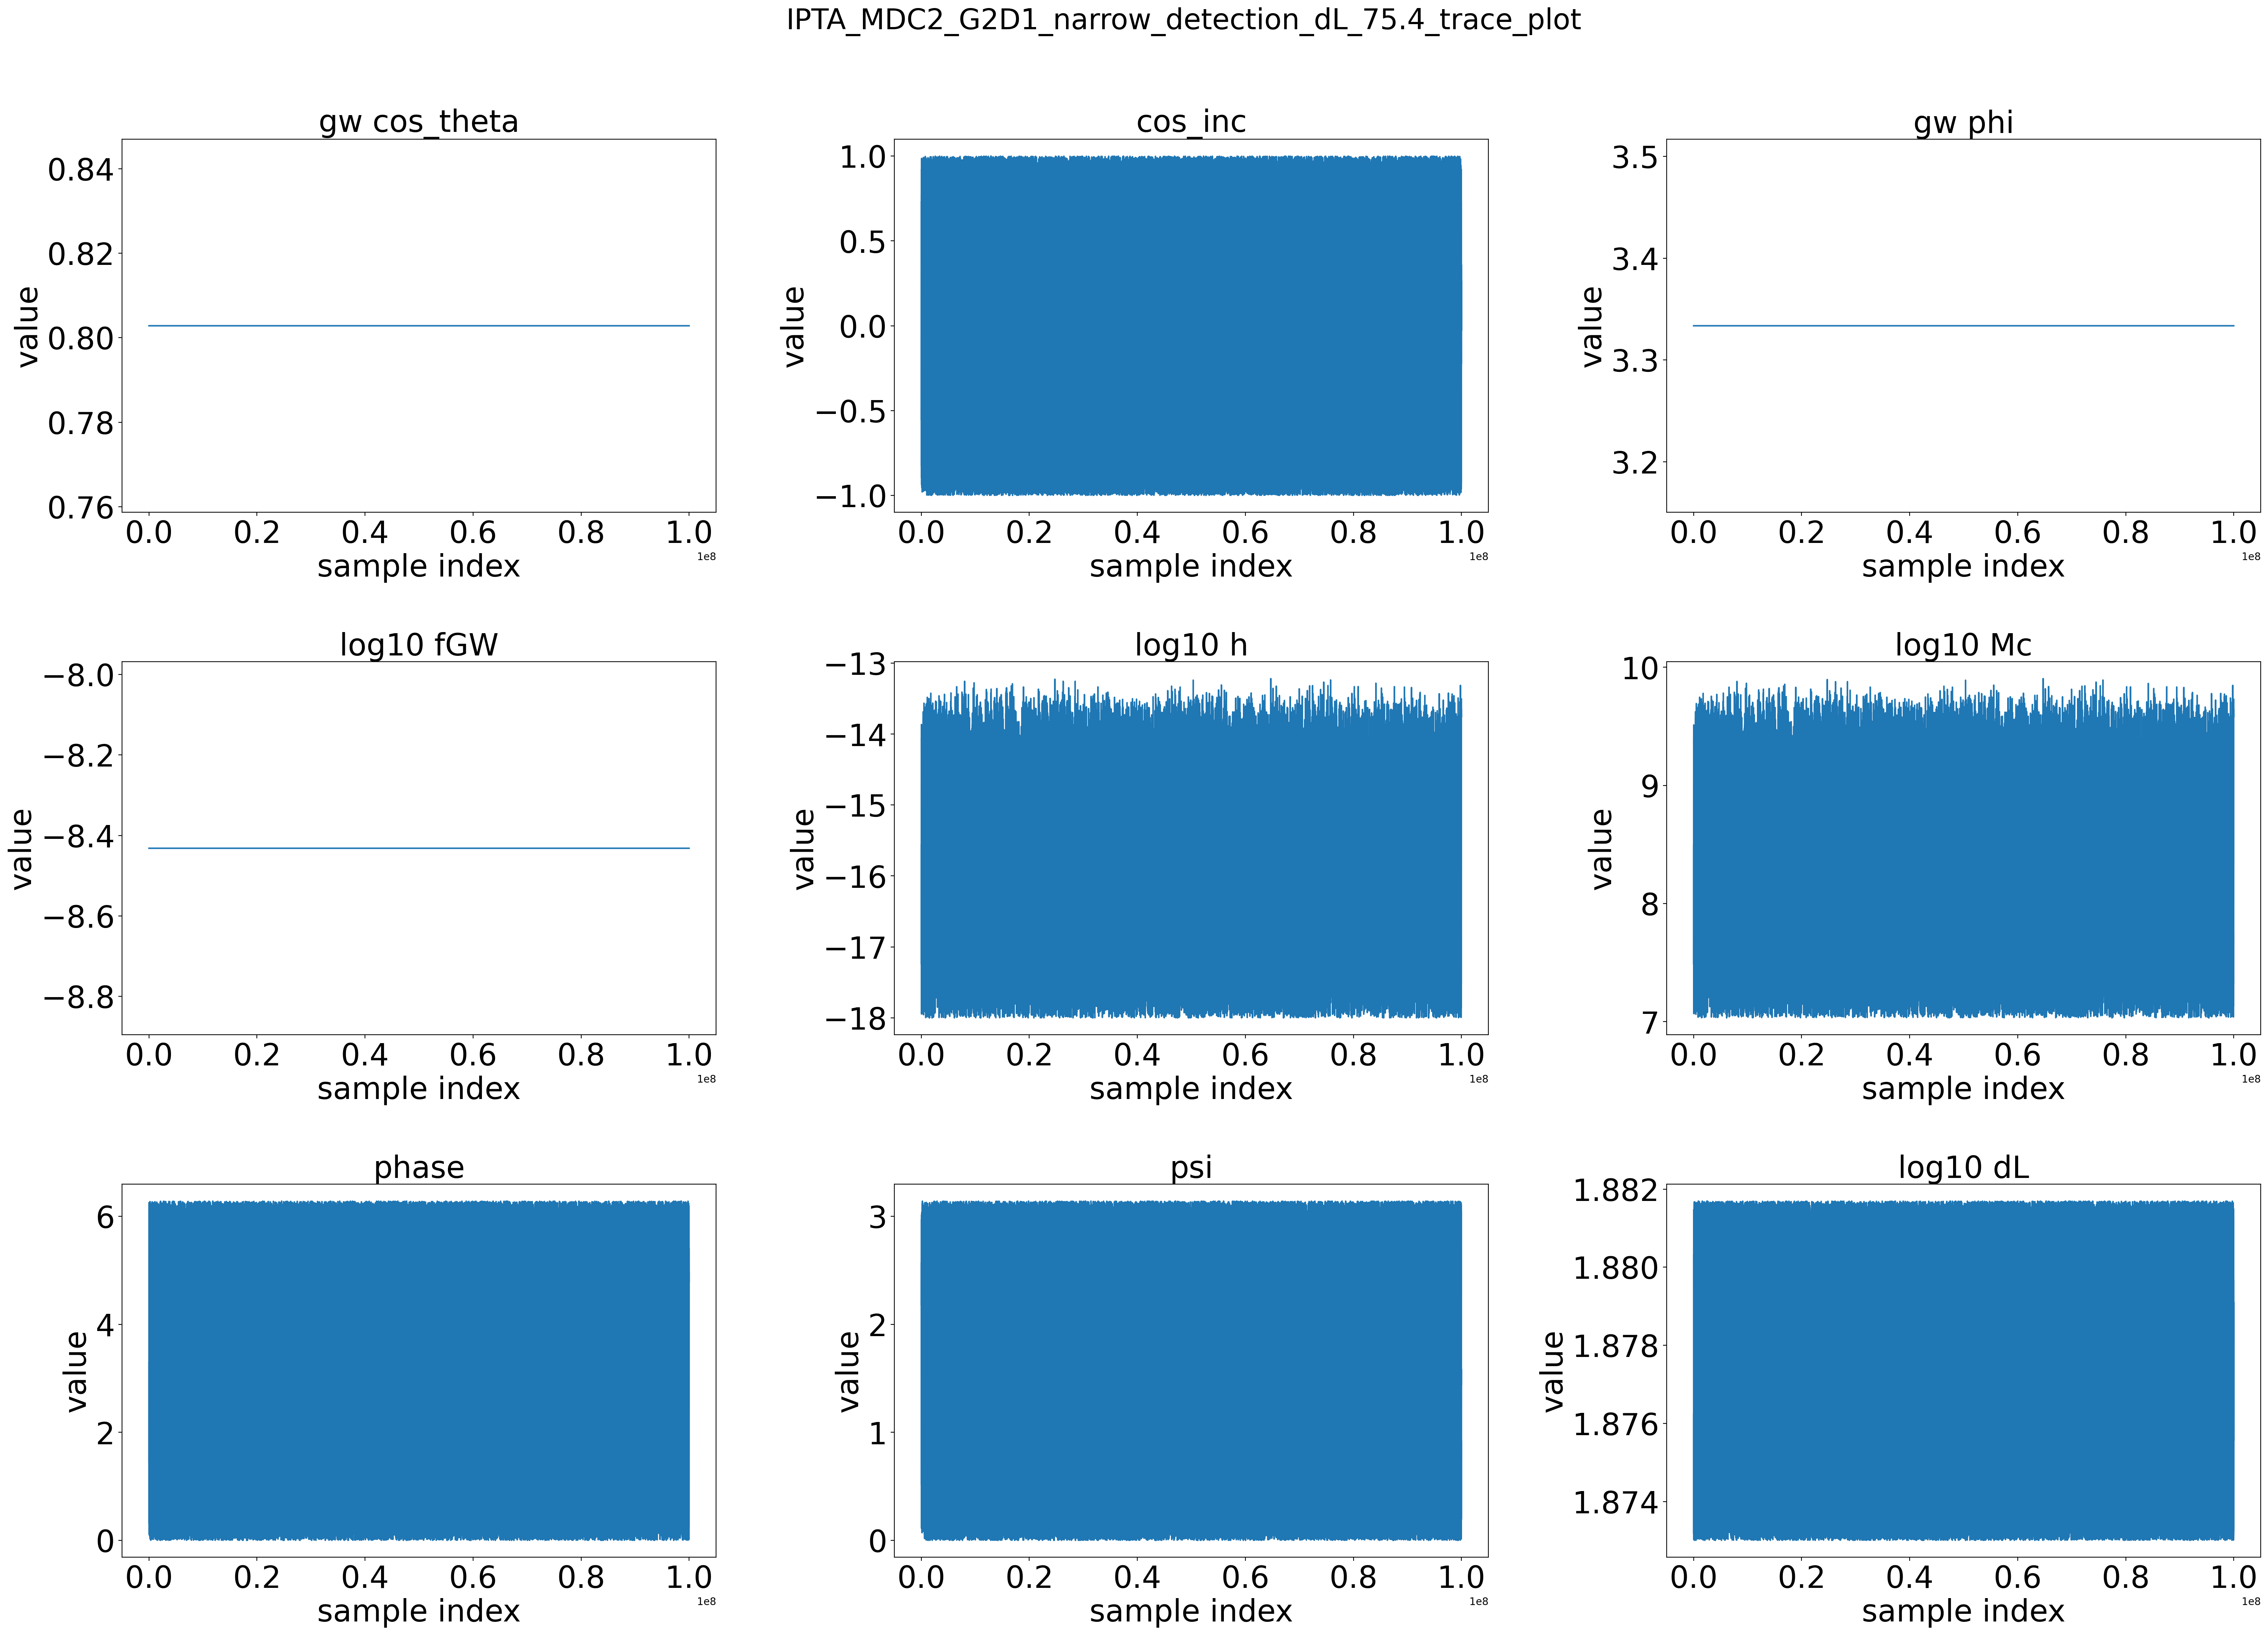

In [9]:
import matplotlib.pyplot as plt

title = ["gw cos_theta", "cos_inc", "gw phi", "log10 fGW", 
         "log10 h", "log10 Mc", "phase", "psi", "log10 dL"]

j = -1
row, column = 3, 3
fig, axs = plt.subplots(row, column, figsize=(30, 20))
fig.tight_layout(h_pad=3, w_pad=2)

# Loop over parameters
for i in range(len(title)): 
    if i % column == 0:
        j += 1
    axs[j, i % column].plot(d_L_mask, samples2plot[d_L_mask, i])
    axs[j, i % column].set_title(title[i], fontsize=30)    # bigger subplot title
    axs[j, i % column].tick_params(axis="both", labelsize=30)  # bigger tick labels
    axs[j, i % column].set_xlabel("sample index", fontsize=30)
    axs[j, i % column].set_ylabel("value", fontsize=30)

# Global title
fig.suptitle(trace_plot_title, fontsize=28, y=1.08)

plt.subplots_adjust(hspace=0.4, wspace=0.3)  # more spacing
#plt.show()
#plt.savefig("trace_plots.png", dpi=200, bbox_inches="tight")


In [10]:
print(np.min(samples2plot[d_L_mask,5]))
print(np.max(np.log10(samples2plot[d_L_mask,5])))

7.0324883e+00
0.9958318


## SD BF

hmin -17.999994
hmax -13.219729
Mc min 7.0324883
Mc max 9.904482
130679


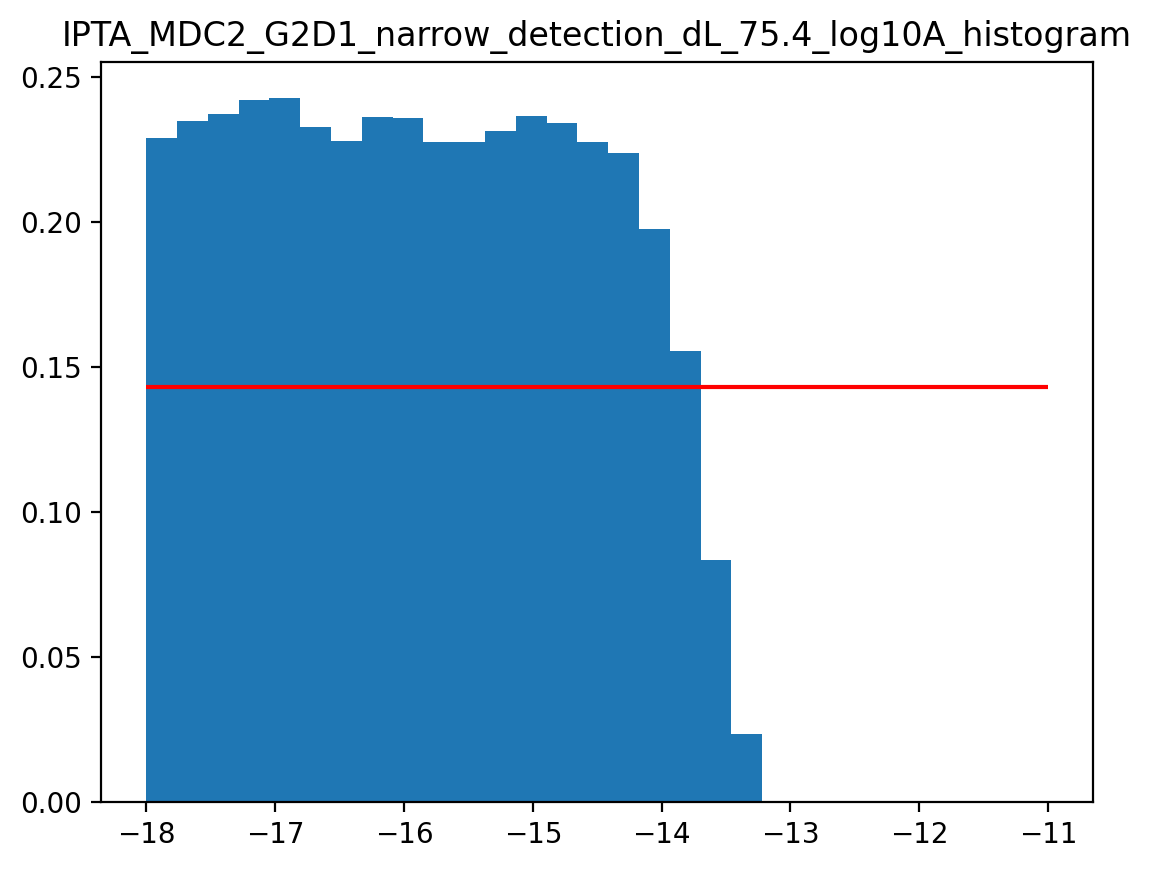

In [11]:
logAmin_dL = np.min(samples2plot[d_L_mask,4])
logAmax_dL = np.max(samples2plot[d_L_mask,4])
print("hmin",logAmin_dL)
print("hmax",logAmax_dL)
print("Mc min",np.min(samples2plot[d_L_mask,5]))
print("Mc max",np.max(samples2plot[d_L_mask,5]))

print(len(samples2plot[d_L_mask,4]))

plt.hist(samples2plot[d_L_mask,4], bins=20, density=True)
plt.hlines(1/(-11 - logAmin_dL), logAmin_dL, -11,  color='red')
plt.title(BF_histogram_title)
plt.show()

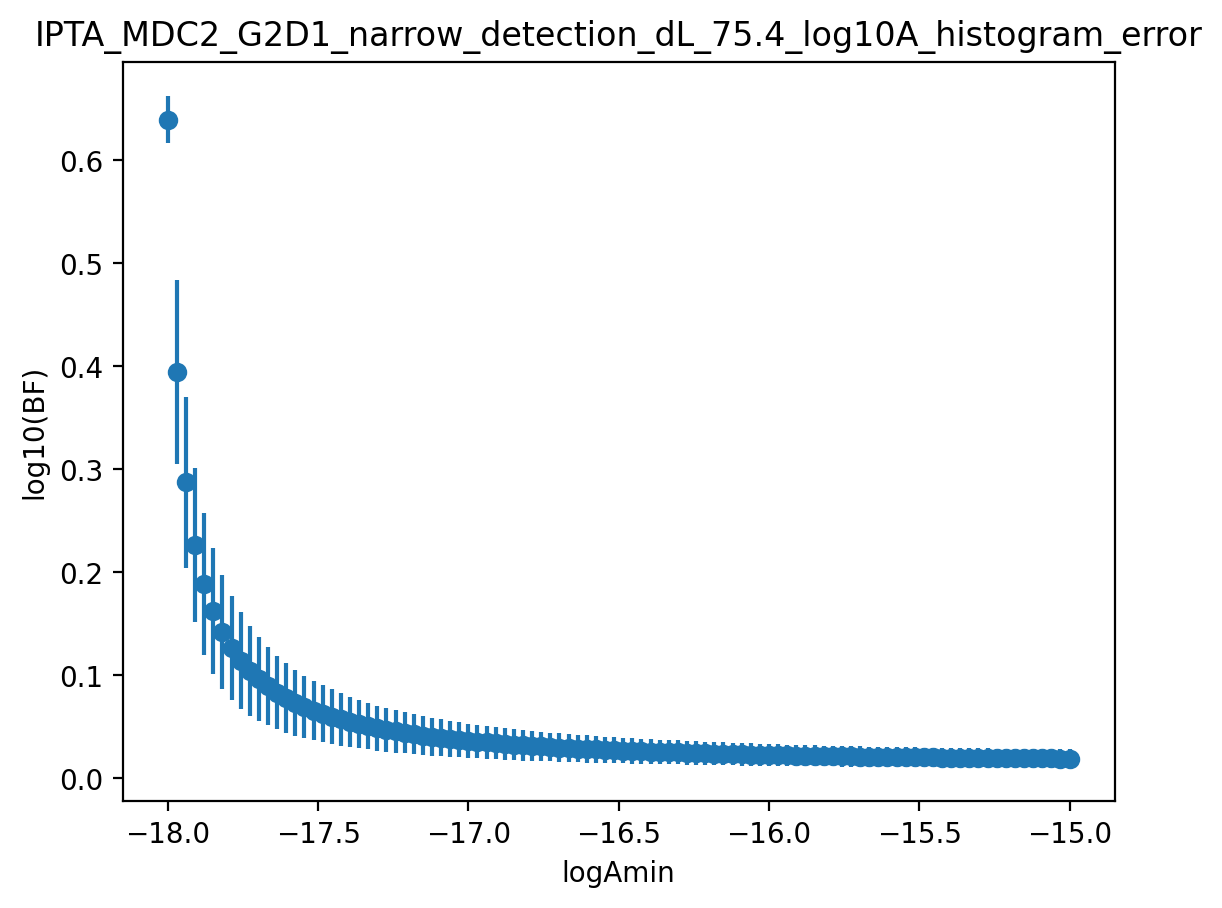

In [12]:
#d_L correlated SD BF
logamins = np.linspace(logAmin_dL, -15, 100)
BF_arr = []
BF_err_arr = []

from enterprise_extensions import model_utils
for logamin in logamins:
    BF,BF_err = model_utils.bayes_fac(samples = samples2plot[d_L_mask,4], logAmin=logamin, logAmax=-11)
    BF_arr.append(BF)
    BF_err_arr.append(BF_err)

plt.errorbar(logamins, BF_arr, yerr=BF_err_arr, fmt='o')
plt.xlabel('logAmin')
plt.ylabel("log10(BF)")
plt.title(BFerr_title)
plt.show()

In [13]:
#d_L correlated SD BF
BF, BF_err = model_utils.bayes_fac(samples=samples2plot[d_L_mask,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = 0.6397 ± 0.0230


In [14]:
#Non d_L correlated SD BF
from enterprise_extensions import model_utils
BF,BF_err = model_utils.bayes_fac(samples = samples_cold[0][::10,4], logAmax=-11)
print(f"log10A BF = {BF:.4f} ± {BF_err:.4f}")

log10A BF = 0.6094 ± 0.0012


In [15]:
print(BF_arr[0:10])

[0.6395826743021206, 0.3944430233226824, 0.28728791024436245, 0.22667499846546604, 0.1887324063785002, 0.16240753028863406, 0.14219118291327243, 0.12645034079189976, 0.11423297657033907, 0.1045856579389755]


In [16]:
print(BF_err_arr[0:10])

[0.023039511620518118, 0.08974118259363074, 0.08288000656694396, 0.07448649187461433, 0.06880039346454542, 0.061644223203891776, 0.055208337476074294, 0.050494888045360925, 0.04682949864765789, 0.04366056099806075]
